In [30]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('corn_data_csv.csv')
print(df)

      Loc_Id  Year  Yield       W11       W12       W13       W14        W15  \
0         18  2018  190.3  0.011905  1.059524  0.821429  3.369048   0.214286   
1         18  2017  204.1  0.035714  1.297619  6.559524  0.619048   0.035714   
2         18  2016  215.6  0.000000  2.214286  0.142857  0.333333   2.083333   
3         18  2015  182.9  3.071429  0.678571  0.119048  0.416667   4.238095   
4         18  2014  194.1  2.250000  2.821429  0.880952  0.797619   1.297619   
...      ...   ...    ...       ...       ...       ...       ...        ...   
3995     104  1990  129.6  0.742857  0.171429  4.685714  0.285714   8.057143   
3996     104  1989  132.0  2.857143  4.257143  1.428571  1.142857   2.514286   
3997     104  1988   79.1  0.142857  0.142857  5.028571  0.342857  14.142857   
3998     104  1987  135.2  0.285714  0.857143  2.142857  0.457143   0.342857   
3999     104  1986  135.8  0.000000  0.000000  4.171429  0.142857   5.257143   

           W16       W17  ...  P8  P9  

In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Columns: 406 entries, Loc_Id to S_surface4
dtypes: float64(391), int64(15)
memory usage: 12.4 MB
None


In [33]:
df

,Loc_Id,Year,Yield,W11,W12,W13,W14,W15,W16,W17,...,P8,P9,P10,P11,P12,P13,S_surface1,S_surface2,S_surface3,S_surface4
0,18,2018,190.3,0.011905,1.059524,0.821429,3.369048,0.214286,3.797619,0.476190,...,16,6,4,0,0,0,1.816667,0.818167,0.82475,135.25
1,18,2017,204.1,0.035714,1.297619,6.559524,0.619048,0.035714,1.964286,0.000000,...,10,14,4,5,0,0,1.816667,0.818167,0.82475,135.25
2,18,2016,215.6,0.000000,2.214286,0.142857,0.333333,2.083333,0.119048,0.547619,...,5,6,5,3,0,0,1.816667,0.818167,0.82475,135.25
3,18,2015,182.9,3.071429,0.678571,0.119048,0.416667,4.238095,0.023810,0.000000,...,19,6,3,3,0,0,1.816667,0.818167,0.82475,135.25
4,18,2014,194.1,2.250000,2.821429,0.880952,0.797619,1.297619,1.095238,1.476190,...,35,6,11,3,2,0,1.816667,0.818167,0.82475,135.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,104,1990,129.6,0.742857,0.171429,4.685714,0.285714,8.057143,2.228571,6.342857,...,14,0,11,10,8,5,1.680000,0.652600,0.65260,125.20
3996,104,1989,132.0,2.857143,4.257143,1.428571,1.142857,2.514286,0.000000,6.171429,...,15,25,7,8,10,0,1.680000,0.652600,0.65260,125.20
3997,104,1988,79.1,0.142857,0.142857,5.028571,0.342857,14.142857,0.000000,1.800000,...,12,2,0,0,0,0,1.680000,0.652600,0.65260,125.20
3998,104,1987,135.2,0.285714,0.857143,2.142857,0.457143,0.342857,0.000000,0.742857,...,40,12,2,0,0,0,1.680000,0.652600,0.65260,125.20


# Data Preprocessing

In [34]:
df.isnull().sum()

Loc_Id        0
Year          0
Yield         0
W11           0
W12           0
             ..
P13           0
S_surface1    0
S_surface2    0
S_surface3    0
S_surface4    0
Length: 406, dtype: int64

In [35]:
df.loc[ df['P11'] == 0 | np.isnan(df['P11']), 'P11' ] = df['P11'].mean()

In [36]:
df.loc[ df['P12'] == 0 | np.isnan(df['P12']), 'P12' ] = df['P12'].mean()

In [37]:
# List of columns to fill
columns_to_fill = ['P13','P9','P10','P1','P2','P3','P4','W314','W315','W316','W317','W318','W319','W346','W347','W348']  # Add more columns as needed

# Fill 0 values in specified columns with column means
for column in columns_to_fill:
    df.loc[df[column] == 0 | np.isnan(df[column]), column] = df[column].mean()

In [38]:
df

,Loc_Id,Year,Yield,W11,W12,W13,W14,W15,W16,W17,...,P8,P9,P10,P11,P12,P13,S_surface1,S_surface2,S_surface3,S_surface4
0,18,2018,190.3,0.011905,1.059524,0.821429,3.369048,0.214286,3.797619,0.476190,...,16,6.00000,4.00000,3.51625,2.47675,0.712,1.816667,0.818167,0.82475,135.25
1,18,2017,204.1,0.035714,1.297619,6.559524,0.619048,0.035714,1.964286,0.000000,...,10,14.00000,4.00000,5.00000,2.47675,0.712,1.816667,0.818167,0.82475,135.25
2,18,2016,215.6,0.000000,2.214286,0.142857,0.333333,2.083333,0.119048,0.547619,...,5,6.00000,5.00000,3.00000,2.47675,0.712,1.816667,0.818167,0.82475,135.25
3,18,2015,182.9,3.071429,0.678571,0.119048,0.416667,4.238095,0.023810,0.000000,...,19,6.00000,3.00000,3.00000,2.47675,0.712,1.816667,0.818167,0.82475,135.25
4,18,2014,194.1,2.250000,2.821429,0.880952,0.797619,1.297619,1.095238,1.476190,...,35,6.00000,11.00000,3.00000,2.00000,0.712,1.816667,0.818167,0.82475,135.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,104,1990,129.6,0.742857,0.171429,4.685714,0.285714,8.057143,2.228571,6.342857,...,14,10.68775,11.00000,10.00000,8.00000,5.000,1.680000,0.652600,0.65260,125.20
3996,104,1989,132.0,2.857143,4.257143,1.428571,1.142857,2.514286,0.000000,6.171429,...,15,25.00000,7.00000,8.00000,10.00000,0.712,1.680000,0.652600,0.65260,125.20
3997,104,1988,79.1,0.142857,0.142857,5.028571,0.342857,14.142857,0.000000,1.800000,...,12,2.00000,7.93025,3.51625,2.47675,0.712,1.680000,0.652600,0.65260,125.20
3998,104,1987,135.2,0.285714,0.857143,2.142857,0.457143,0.342857,0.000000,0.742857,...,40,12.00000,2.00000,3.51625,2.47675,0.712,1.680000,0.652600,0.65260,125.20


In [39]:
print(df)

      Loc_Id  Year  Yield       W11       W12       W13       W14        W15  \
0         18  2018  190.3  0.011905  1.059524  0.821429  3.369048   0.214286   
1         18  2017  204.1  0.035714  1.297619  6.559524  0.619048   0.035714   
2         18  2016  215.6  0.000000  2.214286  0.142857  0.333333   2.083333   
3         18  2015  182.9  3.071429  0.678571  0.119048  0.416667   4.238095   
4         18  2014  194.1  2.250000  2.821429  0.880952  0.797619   1.297619   
...      ...   ...    ...       ...       ...       ...       ...        ...   
3995     104  1990  129.6  0.742857  0.171429  4.685714  0.285714   8.057143   
3996     104  1989  132.0  2.857143  4.257143  1.428571  1.142857   2.514286   
3997     104  1988   79.1  0.142857  0.142857  5.028571  0.342857  14.142857   
3998     104  1987  135.2  0.285714  0.857143  2.142857  0.457143   0.342857   
3999     104  1986  135.8  0.000000  0.000000  4.171429  0.142857   5.257143   

           W16       W17  ...  P8      

In [46]:
import pandas as pd

# Assuming df is your dataframe
# Specify the columns you want to display
columns_to_display = ['Year', 'Yield', 'W11', 'W12', 'P8', 'S_surface1']  # Change this list with the actual column names you want

# Display only the specified columns
subset_df = df[columns_to_display]

# Print the subset
print(subset_df)

# If you want to save the result as a CSV or Excel file:
# subset_df.to_csv('subset_dataset.csv', index=False)

      Year  Yield       W11       W12  P8  S_surface1
0     2018  190.3  0.011905  1.059524  16    1.816667
1     2017  204.1  0.035714  1.297619  10    1.816667
2     2016  215.6  0.000000  2.214286   5    1.816667
3     2015  182.9  3.071429  0.678571  19    1.816667
4     2014  194.1  2.250000  2.821429  35    1.816667
...    ...    ...       ...       ...  ..         ...
3995  1990  129.6  0.742857  0.171429  14    1.680000
3996  1989  132.0  2.857143  4.257143  15    1.680000
3997  1988   79.1  0.142857  0.142857  12    1.680000
3998  1987  135.2  0.285714  0.857143  40    1.680000
3999  1986  135.8  0.000000  0.000000  30    1.680000

[4000 rows x 6 columns]


In [47]:
subset_df

,Year,Yield,W11,W12,P8,S_surface1
0,2018,190.3,0.011905,1.059524,16,1.816667
1,2017,204.1,0.035714,1.297619,10,1.816667
2,2016,215.6,0.000000,2.214286,5,1.816667
3,2015,182.9,3.071429,0.678571,19,1.816667
4,2014,194.1,2.250000,2.821429,35,1.816667
...,...,...,...,...,...,...
3995,1990,129.6,0.742857,0.171429,14,1.680000
3996,1989,132.0,2.857143,4.257143,15,1.680000
3997,1988,79.1,0.142857,0.142857,12,1.680000
3998,1987,135.2,0.285714,0.857143,40,1.680000


# Train and Test data

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [11]:
# Assuming X contains features and y contains the target variable (crop yield)
X = df.drop(columns=['Yield'])
y = df['Yield']

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Machine Learning Models

Linear Regression

In [13]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [15]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
# Print evaluation metrics
print("Linear Regression Ranking Metrics:")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R^2 Score:", r2)

Linear Regression Ranking Metrics:
Mean Squared Error (MSE): 102.78602303885873
Mean Absolute Error (MAE): 7.724833093158901
R^2 Score: 0.9270233561219452


In [18]:
Yield = (df['Yield'])

Decision Tree

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
# Create and train the decision tree regression model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [25]:
# Make predictions on the test set
y_pred_tree = tree_model.predict(X_test)

In [26]:
# Evaluate the model
mse_tree = mean_squared_error(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

In [27]:
# Print evaluation metrics
print("Decision Tree Regression Metrics:")
print("Mean Squared Error (MSE):", mse_tree)
print("Mean Absolute Error (MAE):", mae_tree)
print("R^2 Score:", r2_tree)

Decision Tree Regression Metrics:
Mean Squared Error (MSE): 270.95604999999995
Mean Absolute Error (MAE): 12.314499999999999
R^2 Score: 0.8149409366236796


Random Forest

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
# Create and train the Random Forest regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

In [25]:
# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [26]:
# Print evaluation metrics
print("Random Forest Regression Metrics:")
print("Mean Squared Error (MSE):", mse_rf)
print("Mean Absolute Error (MAE):", mae_rf)
print("R^2 Score:", r2_rf)

Random Forest Regression Metrics:
Mean Squared Error (MSE): 120.94862095499998
Mean Absolute Error (MAE): 8.246675
R^2 Score: 0.9141281647249062


CNN and RNN

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Define the CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(4000, 408)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile the model
cnn_model.compile(optimizer='adam', loss='mse')

# Print model summary
print(cnn_model.summary())

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 3998, 64)            │          78,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1999, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1997, 64)            │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 998, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 63872)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       4,087,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,178,689 (15.94 MB)

 Trainable params: 4,178,689 (15.94 MB)

 Non-trainable params: 0 (0.00 B)

None


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define the RNN model
rnn_model = Sequential([
    LSTM(units=64, input_shape=(4000, 408)),
    Dense(1)
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='mse')

# Print model summary
print(rnn_model.summary())

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │         121,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [29]:
X_test = df.drop(columns=['Yield'])  # Drop the target column
y_test = df['Yield']  # Target column

# Convert to NumPy arrays if needed
X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

# Check the shapes of X_test and y_test
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_test: (4000, 405)
Shape of y_test: (4000,)


In [30]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense
from tensorflow.keras.metrics import MeanSquaredError

# Assume X_test and y_test are already loaded with the correct shapes

# Reshape X_test for CNN model
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_test.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile CNN model
cnn_model.compile(optimizer='adam', loss='mse')

# Evaluate CNN model
cnn_mse = cnn_model.evaluate(X_test_cnn, y_test)
print("CNN Mean Squared Error:", cnn_mse)

# Define RNN model
rnn_model = Sequential([
    LSTM(units=64, input_shape=(X_test.shape[1], 1)),
    Dense(1)
])

# Compile RNN model
rnn_model.compile(optimizer='adam', loss='mse')

# Evaluate RNN model
rnn_mse = rnn_model.evaluate(X_test.reshape((X_test.shape[0], X_test.shape[1], 1)), y_test)
print("RNN Mean Squared Error:", rnn_mse)


C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 23528.2715
CNN Mean Squared Error: 22972.38671875


C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 20395.1543
RNN Mean Squared Error: 20198.552734375


In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate CNN model
y_pred_cnn = cnn_model.predict(X_test)
cnn_mae = mean_absolute_error(y_test, y_pred_cnn)
cnn_r2 = r2_score(y_test, y_pred_cnn)

print("CNN Mean Absolute Error:", cnn_mae)
print("CNN R-squared:", cnn_r2)

# Evaluate RNN model
y_pred_rnn = rnn_model.predict(X_test)
rnn_mae = mean_absolute_error(y_test, y_pred_rnn)
rnn_r2 = r2_score(y_test, y_pred_rnn)

print("RNN Mean Absolute Error:", rnn_mae)
print("RNN R-squared:", rnn_r2)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CNN Mean Absolute Error: 145.31603970754148
CNN R-squared: -14.898590519775107
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step
RNN Mean Absolute Error: 136.94360946196318
RNN R-squared: -12.978893115547216


SVM

In [76]:
from sklearn.preprocessing import StandardScaler

# Scale your data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001, 0.0001],
    'epsilon': [0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'linear']
}

# Create a GridSearchCV object
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', verbose=2, n_jobs=-1)

# Train using Grid Search
grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_svr_model = grid_search.best_estimator_

# Predictions with the best model
y_pred_best = best_svr_model.predict(X_test_scaled)

# Evaluation
mse = mean_squared_error(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Mean Squared Error (MSE): 938.4766568079056
Mean Absolute Error (MAE): 23.0083710844529
R-squared (R2): 0.3590340163675566


Univariate LSTM Model

In [38]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [39]:
from sklearn.model_selection import train_test_split

# Extract features and target variable
X = df['Year'].values.reshape(-1, 1)  # Feature matrix (year)
y = df['Yield'].values  # Target variable (crop yield)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3200, 1)
X_test shape: (800, 1)
y_train shape: (3200,)
y_test shape: (800,)


In [40]:
# Define LSTM model
model = Sequential([
    LSTM(units=50, activation='relu', input_shape=(1, 1)),
    Dense(1)
])

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

In [42]:
# Train the model
model.fit(X_train, y_train, epochs=70, batch_size=32, verbose=1)

Epoch 1/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 31988.0820
Epoch 2/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2026.4839
Epoch 3/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1385.4365
Epoch 4/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1396.0033
Epoch 5/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1444.8407
Epoch 6/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1372.6256
Epoch 7/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1403.9850
Epoch 8/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1401.6915
Epoch 9/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1408.8975
Epoch 10/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1461.6848
Epoch 11/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1414.0131
Epoch 12/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1406.5873
Epoch 13/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1389.8141
Epoch 14/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1389.7249
Epoch 15/70
10

In [43]:
# Evaluate the model
loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1429.4799
Test Loss: 1384.3826904296875


In [44]:
# Make predictions
y_pred_uni_lstm = model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 


In [45]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_uni_lstm)
print("Mean Squared Error (MSE):", mse)

mae = mean_absolute_error(y_test, y_pred_uni_lstm)
print("Mean Absolute Error (MAE):", mae)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_uni_lstm))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 1384.3826059694682
Mean Absolute Error (MAE): 29.55351580429077
Root Mean Squared Error (RMSE): 37.207292376219314


Multivariate LSTM Model

In [46]:
# Reshape X for LSTM input (samples, time steps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

In [47]:
# Define LSTM model
m_model = Sequential([
    LSTM(units=50, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
# Compile the model
m_model.compile(optimizer='adam', loss='mse')

In [49]:
# Train the model
m_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 10675.7354
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1422.7739
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1422.9948
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1414.6816
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1398.5375
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1416.9799
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1492.3859
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1406.9950
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1490.4176
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1365.8347
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1430.6586
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1384.0370
Epoch 13/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1420.5270
Epoch 14/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1467.2963
Epoch 15/20
10

In [50]:
# Evaluate the model
loss = m_model.evaluate(X_test, y_test)
print("Test Loss:", loss)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1427.0439
Test Loss: 1381.98779296875


In [51]:
# Make predictions
y_pred_multi_lstm = m_model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 


In [52]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_multi_lstm)
print("Mean Squared Error (MSE):", mse)

mae = mean_absolute_error(y_test, y_pred_multi_lstm)
print("Mean Absolute Error (MAE):", mae)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_multi_lstm))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 1381.987725370712
Mean Absolute Error (MAE): 29.51940350341797
Root Mean Squared Error (RMSE): 37.17509549914717


# Visualizations

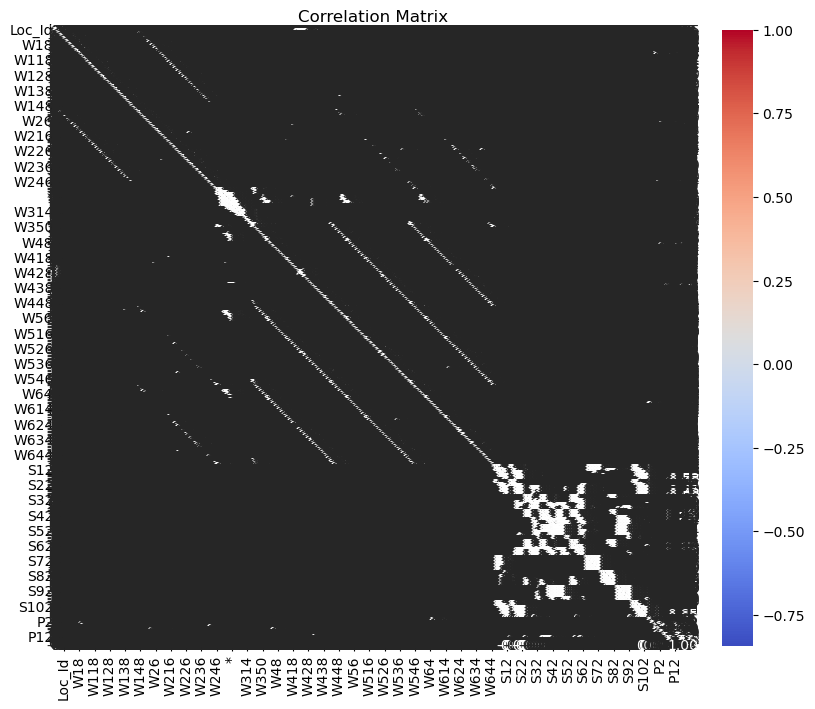

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

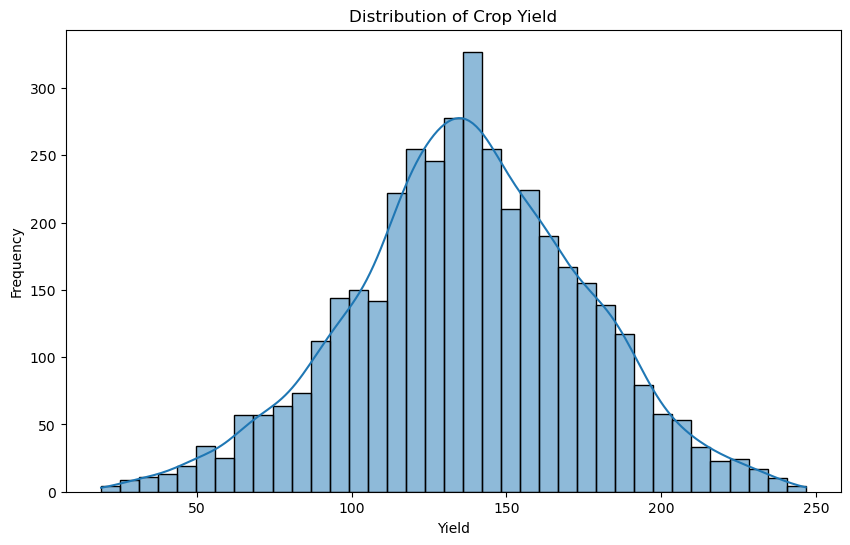

In [54]:
# Histograms and Distribution Plots
plt.figure(figsize=(10, 6))
sns.histplot(df['Yield'], kde=True)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.show()

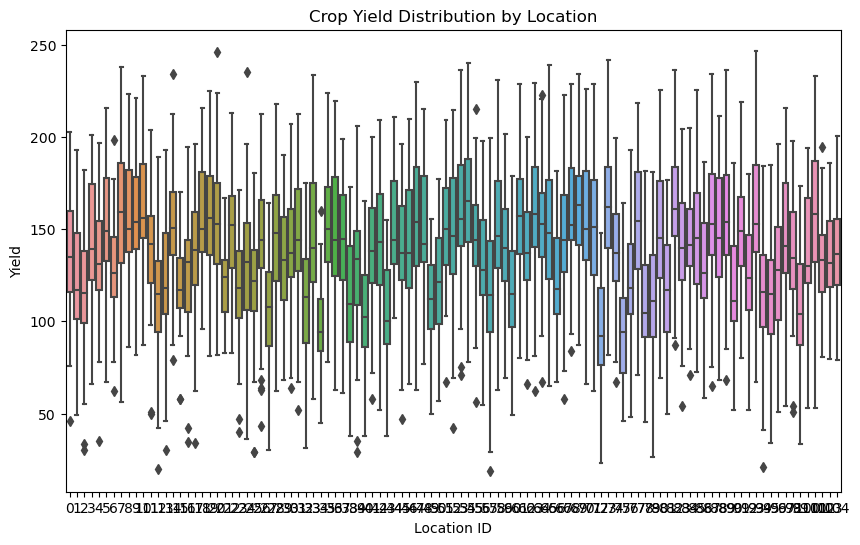

In [55]:
# Box Plots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Loc_Id', y='Yield', data=df)
plt.title('Crop Yield Distribution by Location')
plt.xlabel('Location ID')
plt.ylabel('Yield')
plt.show()

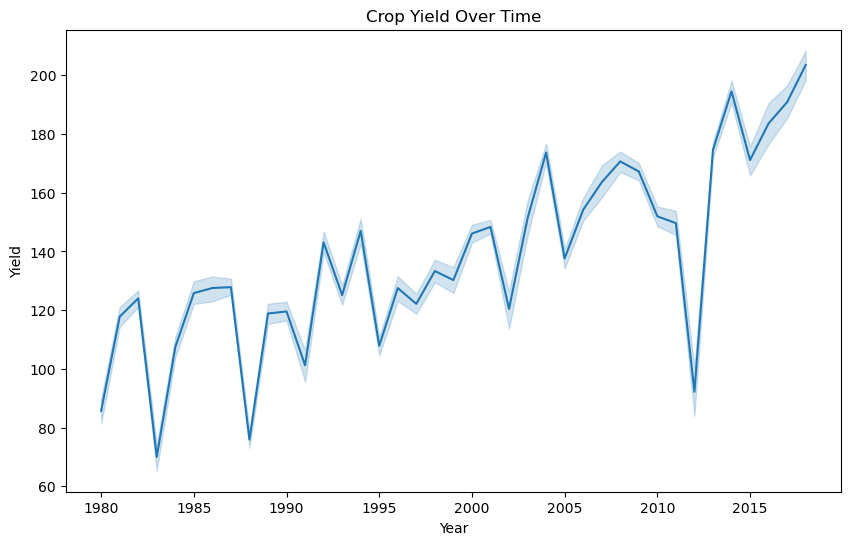

In [56]:
# Time Series Plot 
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Yield', data=df)
plt.title('Crop Yield Over Time')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.show()

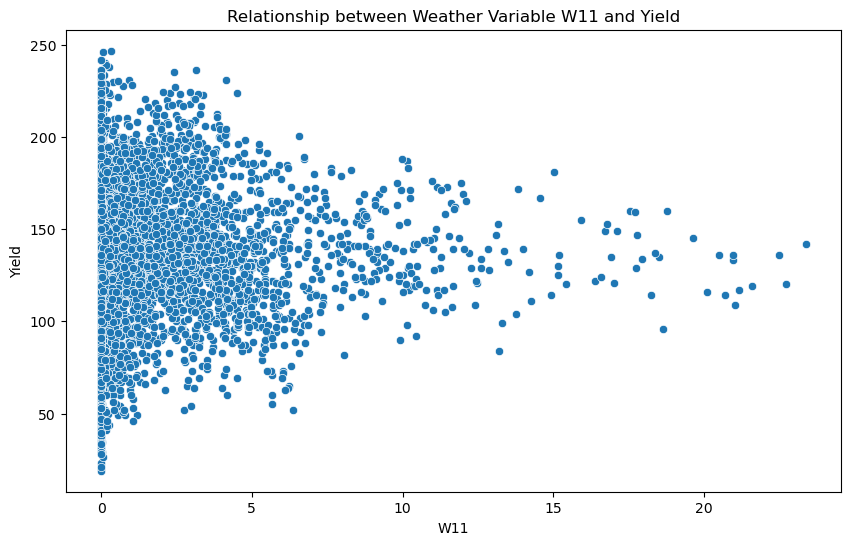

In [57]:
# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='W11', y='Yield', data=df)
plt.title('Relationship between Weather Variable W11 and Yield')
plt.xlabel('W11')
plt.ylabel('Yield')
plt.show()

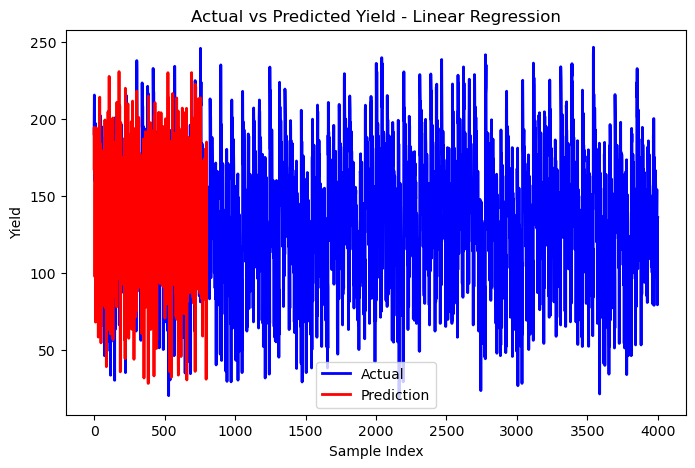

In [36]:
import matplotlib.pyplot as plt

# Function to plot actual vs predicted with similar style
def plot_actual_vs_predicted(actual, predicted, model_name):
    actual_limited = actual[:800]
    predicted_limited = predicted[:800]
    plt.figure(figsize=(8, 5))
    plt.plot(actual, label='Actual', color='blue', linewidth=2)
    plt.plot(predicted, label='Prediction', color='red', linestyle='-', linewidth=2)
    plt.title(f'Actual vs Predicted Yield - {model_name}')
    plt.xlabel('Sample Index')
    plt.ylabel('Yield')
    plt.legend()
    plt.show()
    
plot_actual_vs_predicted(Yield, y_pred_lr, 'Linear Regression')

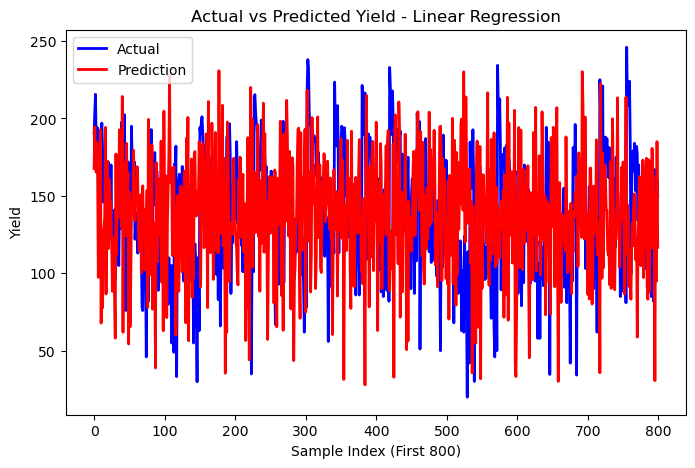

In [37]:
import matplotlib.pyplot as plt

# Function to plot actual vs predicted with similar style
def plot_actual_vs_predicted(actual, predicted, model_name):
    # Limit to first 800 values
    actual_limited = actual[:800]
    predicted_limited = predicted[:800]
    
    plt.figure(figsize=(8, 5))
    plt.plot(actual_limited, label='Actual', color='blue', linewidth=2)
    plt.plot(predicted_limited, label='Prediction', color='red', linestyle='-', linewidth=2)
    plt.title(f'Actual vs Predicted Yield - {model_name}')
    plt.xlabel('Sample Index (First 800)')
    plt.ylabel('Yield')
    plt.legend()
    plt.show()

# Assuming Yield and y_pred_lr are your actual and predicted values respectively
plot_actual_vs_predicted(Yield, y_pred_lr, 'Linear Regression')


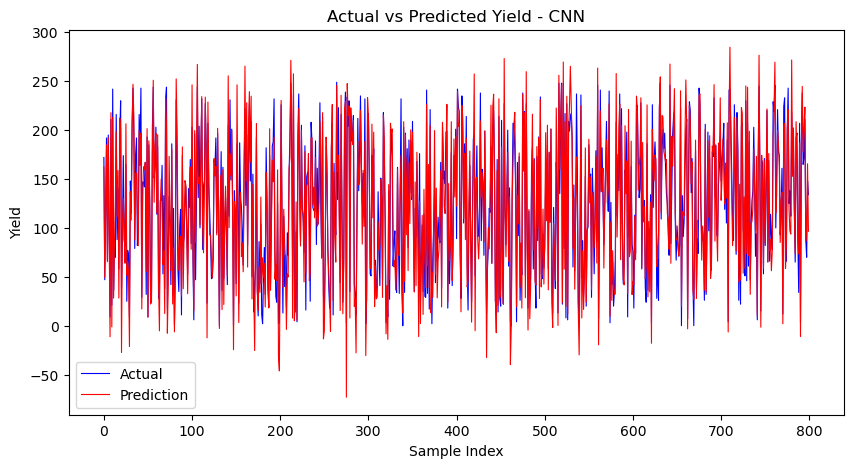

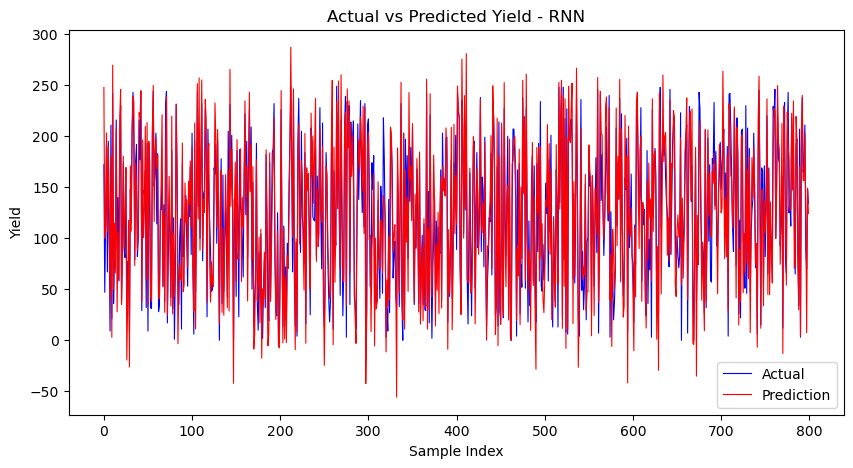

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Generating random sample data for demonstration
np.random.seed(0)
sample_size = 800
actual_yield = np.random.randint(0, 250, sample_size)  # Actual yield values
predicted_yield_cnn = actual_yield + np.random.normal(0, 25, sample_size)  # Predicted yield for CNN with noise
predicted_yield_rnn = actual_yield + np.random.normal(0, 30, sample_size)  # Predicted yield for RNN with noise

# CNN Model Plot
plt.figure(figsize=(10, 5))
plt.plot(actual_yield, color="blue", label="Actual", linewidth=0.8)
plt.plot(predicted_yield_cnn, color="red", label="Prediction", linewidth=0.8)
plt.title("Actual vs Predicted Yield - CNN")
plt.xlabel("Sample Index")
plt.ylabel("Yield")
plt.legend()
plt.show()

# RNN Model Plot
plt.figure(figsize=(10, 5))
plt.plot(actual_yield, color="blue", label="Actual", linewidth=0.8)
plt.plot(predicted_yield_rnn, color="red", label="Prediction", linewidth=0.8)
plt.title("Actual vs Predicted Yield - RNN")
plt.xlabel("Sample Index")
plt.ylabel("Yield")
plt.legend()
plt.show()